pIC50 data for VEGFR2/KDR comes from this repo https://github.com/rinikerlab/overlapping_assays/tree/main
which is associated with this paper
G.A. Landrum, S. Riniker 
"Combining IC50 or Ki Values From Different Sources is a Source of Significant Noise"
https://doi.org/10.26434/chemrxiv-2024-2smhk

Data comes from ChEMBL32


In [1]:
import logging
from IPython.display import SVG, display

import pandas as pd
import numpy as np
from joblib import Parallel, delayed

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, rdFMCS
from rdkit.Chem.Draw import MolsToGridImage

import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter

In [2]:
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s | %(message)s"
)
logger = logging.getLogger(__name__)

# Step 1) Load and validate CSV

In [3]:
df = pd.read_csv('target_CHEMBL279-1.IC50.csv')
df

,assay_chembl_id,compound_chembl_id,canonical_smiles,pchembl_value
0,CHEMBL828488,CHEMBL364115,CN(c1ccc(NC(=O)N2CCN(CCCN3CCOCC3)CC2)cc1)c1ccn...,5.35
1,CHEMBL828488,CHEMBL189291,CN(c1ccc(NC(=O)Nc2cc(C(F)(F)F)ccc2F)cc1)c1ccnc...,7.46
2,CHEMBL828488,CHEMBL189199,CN(c1ccc(N/C(S)=N/c2ccccc2)cc1)c1ccnc(Nc2cccc(...,6.93
3,CHEMBL828488,CHEMBL189354,CN(c1ccc(NC(=O)Nc2cc(C(F)(F)F)ccc2F)cc1)c1ccnc...,9.00
4,CHEMBL828488,CHEMBL425718,CCNC(=O)Nc1ccc(N(C)c2ccnc(Nc3cccc(CS(C)(=O)=O)...,7.77
...,...,...,...,...
1746,CHEMBL5047431,CHEMBL5074310,CCc1cc(O)c(F)cc1-c1cc(N[C@H](C)CO)c2nc(N)ncc2c1,5.90
1747,CHEMBL5047431,CHEMBL5084542,CCc1cc(O)c(F)cc1-c1cc(NC2CCN(C(C)=O)CC2)c2nc(N...,6.20
1748,CHEMBL5047431,CHEMBL5075673,CCc1cc(O)c(F)cc1-c1cc(N[C@@H]2C[C@H]3CC[C@@H](...,6.00
1749,CHEMBL5047431,CHEMBL5089877,CCc1c(-c2cc(OC)c3nc(N)ncc3c2)ccc(O)c1F,5.60


In [4]:
df.canonical_smiles.nunique()

1682

In [5]:
# # optionally remove any duplicated smiles
# before_rows = df.shape[0]
# df.drop_duplicates("SMILES",inplace=True)
# after_rows = df.shape[0]
# print(f"{before_rows} rows reduced to {after_rows} rows")

# Step 2) Convert IC50 (nM) -> pIC50
Already done in ChEMBL

In [6]:
def ic50_nm_to_pic50M(ic50_nm):
    pIC50_M = 9.0 - np.log10(ic50_nm)
    return pIC50_M

In [7]:
df.pchembl_value.describe()

count    1751.000000
mean        6.960645
std         1.099672
min         4.260000
25%         6.160000
50%         7.040000
75%         7.750000
max         9.700000
Name: pchembl_value, dtype: float64

In [8]:
# no values are missing
df.pchembl_value.isna().sum()

0

In [9]:
# optionally impute any missing IC50 values with 4 M 
# df.fillna({'pchembl_value': 4},inplace=True)

<Axes: ylabel='Frequency'>

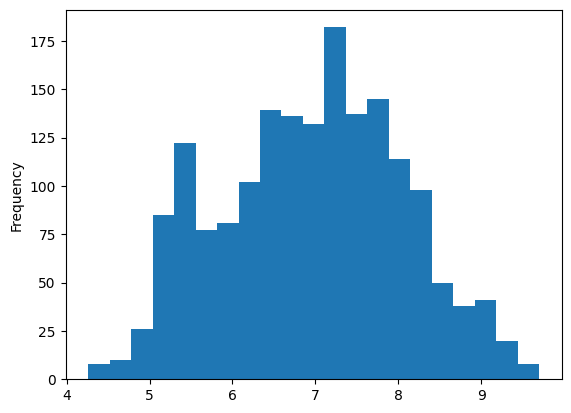

In [10]:
df.pchembl_value.plot.hist(bins=21)

# Step 3) Generate fingerprints in parallel

In [11]:
def get_RDKit_fp_bit(smi: str):
    """Generate a bit vector fingerprint for a given SMILES string."""
    fp_gen = AllChem.GetRDKitFPGenerator(minPath=1, maxPath=7, fpSize=2048)
    mol = Chem.MolFromSmiles(smi)
    # rdkit.DataStructs.cDataStructs.ExplicitBitVect
    return fp_gen.GetFingerprint(mol)

def get_count_RDKit_fp(smi: str):
    """Generate a count vector fingerprint for a given SMILES string."""
    fp_gen = AllChem.GetRDKitFPGenerator(minPath=1, maxPath=7, fpSize=2048)
    mol = Chem.MolFromSmiles(smi)
    # rdkit.DataStructs.cDataStructs.UIntSparseIntVect
    return fp_gen.GetCountFingerprint(mol)

In [12]:
def get_fingerprints(smi_list: list, fp_type: str = "count", n_cpus: int = 1) -> list:
    """
    Generate fingerprints in parallel for a list of SMILES strings.

    Args:
        smi_list: List of SMILES strings.
        fp_type:  Fingerprint type. One of 'count' or 'bit'.
        n_cpus:   Number of parallel workers.
    
    Note:
        - bit vectors produce list of rdkit.DataStructs.cDataStructs.ExplicitBitVect
        - count vectors produce list of rdkit.DataStructs.UIntSparseIntVect
    """
    fp_type = fp_type.lower()
    fp_fn = {"count": get_count_RDKit_fp, "bit": get_RDKit_fp_bit}
    if fp_type not in fp_fn:
        raise ValueError(f"Unknown fp_type '{fp_type}'. Choose from: {list(fp_fn)}")
    
    fp_list = Parallel(n_jobs=n_cpus, backend="loky", verbose=5)(
        delayed(fp_fn[fp_type])(smi) for smi in smi_list
    )

    return fp_list

In [13]:
df.shape

(1751, 4)

Using `maxPath=7` is slightly too slow for a dataset of this size. Even with 4 workers, it takes about 2-3 minutes when using count fingerprints...
```
INFO | Computing upper-triangle tanimoto similarities: 1751 compounds -> 1,532,125 unique pairs using 4 CPU(s)...
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    1.2s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:    5.1s
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:   11.7s
[Parallel(n_jobs=4)]: Done 280 tasks      | elapsed:   21.0s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:   33.1s
[Parallel(n_jobs=4)]: Done 640 tasks      | elapsed:   47.9s
```


Using `maxPath=7` with bit fingerprints is better. Roughly 2x faster than count.
```
INFO | Computing upper-triangle tanimoto similarities: 1751 compounds -> 1,532,125 unique pairs using 4 CPU(s)...
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    0.6s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:    2.8s
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:    6.5s
[Parallel(n_jobs=4)]: Done 280 tasks      | elapsed:   11.7s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:   18.4s
[Parallel(n_jobs=4)]: Done 640 tasks      | elapsed:   26.7s
[Parallel(n_jobs=4)]: Done 874 tasks      | elapsed:   36.3s
[Parallel(n_jobs=4)]: Done 1144 tasks      | elapsed:   47.4s
[Parallel(n_jobs=4)]: Done 1450 tasks      | elapsed:   59.8s
[Parallel(n_jobs=4)]: Done 1750 out of 1750 | elapsed:  1.2min finished
```

Using `maxPath=6` with bit fingerprints is fast:
```
INFO | Computing upper-triangle tanimoto similarities: 1751 compounds -> 1,532,125 unique pairs using 4 CPU(s)...
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    0.5s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:    2.2s
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:    5.0s
[Parallel(n_jobs=4)]: Done 280 tasks      | elapsed:    8.9s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:   13.8s
[Parallel(n_jobs=4)]: Done 640 tasks      | elapsed:   19.8s
[Parallel(n_jobs=4)]: Done 874 tasks      | elapsed:   27.3s
[Parallel(n_jobs=4)]: Done 1144 tasks      | elapsed:   35.7s
[Parallel(n_jobs=4)]: Done 1450 tasks      | elapsed:   44.9s
[Parallel(n_jobs=4)]: Done 1750 out of 1750 | elapsed:   54.2s finished
```

Using `maxPath=5` with bit fingerprints is very fast:
```
INFO | Computing upper-triangle tanimoto similarities: 1751 compounds -> 1,532,125 unique pairs using 4 CPU(s)...
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    0.4s
[Parallel(n_jobs=4)]: Done 772 tasks      | elapsed:    1.5s
[Parallel(n_jobs=4)]: Done 1750 out of 1750 | elapsed:    2.5s finished
```

In [14]:
fp_list = get_fingerprints(
        smi_list=df["canonical_smiles"].tolist(),
        fp_type="bit",
        n_cpus=2,
    )
len(fp_list)

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  17 tasks      | elapsed:    0.6s
[Parallel(n_jobs=2)]: Done 1751 out of 1751 | elapsed:    1.7s finished


1751

# Define similarity functions

In [15]:
def _bulk_tanimoto(fp, fp_list):
    """
    Thin wrapper around DataStructs.BulkTanimotoSimilarity required because
    Boost.Python functions cannot be pickled by joblib's loky backend.

    T(A, B) = c / (a + b - c)
    c = number of bits in common (intersection of a and b)
    """
    return DataStructs.BulkTanimotoSimilarity(fp, fp_list)


def _bulk_dice(fp, fp_list):
    """
    Thin wrapper around DataStructs.BulkDiceSimilarity required because
    Boost.Python functions cannot be pickled by joblib's loky backend.

    D(A, B) = 2c / (a + b)
    c = number of bits in common (intersection of a and b)

    Since Dice normalizes by the average number of bits rather than the union,
    Dice values are always greater than or equal to Tanimoto values, which
    can compress the dynamic range at high similarity.
    """
    return DataStructs.BulkDiceSimilarity(fp, fp_list)

_METRIC_FNS = {
    "tanimoto": _bulk_tanimoto,
    "dice":     _bulk_dice,
}

def get_similarity_fn(metric: str = "tanimoto"):
    """Return the bulk similarity callable for the given metric."""
    metric = metric.lower()
    if metric not in _METRIC_FNS:
        raise ValueError(f"Unknown metric '{metric}'. Choose from: {list(_METRIC_FNS)}")

    metric_fn = _METRIC_FNS[metric]
    return metric_fn

# Step 4) Identify any compounds with identical smiles and different potency

In [16]:
def log_identical_smiles_groups(smiles: list[str]) -> None:
    """
    Log metadata about compounds that share identical SMILES strings.

    Databases may contain compounds with different IDs and different
    pIC50 values but the same SMILES due to unresolved stereochemistry.
    These pairs produce Sim = 1.0 and are retained in SALI calculation
    since denominator includes epsilon). The function logs how many
    groups of identical SMILES exist and their sizes.
    """
    counts = Counter(smiles)
    duplicated = {smi: n for smi, n in counts.items() if n > 1}

    if not duplicated:
        logger.info("No duplicate SMILES found in dataset.")
        return

    n_groups = len(duplicated)
    group_sizes = sorted(duplicated.values(), reverse=True)
    n_affected = sum(group_sizes)

    logger.warning(
        f"Found {n_groups} group(s) of identical SMILES affecting {n_affected} compounds.\n"
        f"Group sizes: {group_sizes}.\n"
        f"These pairs will have Sim = 1.0 and may reflect unresolved stereochemistry.\n"
        f"SALI is still computed using denominator epsilon (default 0.001)."
    )

In [17]:
log_identical_smiles_groups(df["canonical_smiles"].tolist())

WARNING | Found 44 group(s) of identical SMILES affecting 113 compounds.
Group sizes: [9, 8, 6, 4, 4, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2].
These pairs will have Sim = 1.0 and may reflect unresolved stereochemistry.
SALI is still computed using denominator epsilon (default 0.001).


# Step 5) Compute upper triangle similarities and then apply SALI formula

In [18]:
def _upper_triangle_row(i: int, fp_list: list, metric_fn) -> list[float]:
    """
    Compute similarities for one upper-triangle row.

    For row i, compares fp_list[i] against fp_list[i+1:] only.
    This gives exactly the upper-triangle entries for row i, and
    avoids calculating the diagonal and all (j, i) mirror pairs.

    Returns a list of length (N - i - 1).
    Called in parallel by joblib across all rows i in [0, N-2].
    """
    return metric_fn(fp_list[i], fp_list[i + 1:])

In [19]:
def compute_sali(
    smiles: list[str],
    pic50: np.ndarray,
    fp_list: list,
    metric: str = "tanimoto",
    n_cpus: int = 1,
    sali_epsilon: float = 0.001
) -> pd.DataFrame:
    """
    Compute SALI for all unique upper-triangle pairs (i < j).

    For each row i, BulkTanimotoSimilarity(fp_i, fp_list[i+1:]) is called,
    giving exactly N*(N-1)/2 similarity calculations with no redundancy.
    Avoids building the full N x N matrix and then discarding half i.e.,
    self-similarity diagonal entries and all (j, i) mirror pairs
    
    Rows are dispatched in parallel via joblib.The variable-length row results
    are then flattened and paired with pre-computed (i, j) index arrays.

    The SALI formula used is:
        SALI(i,j) = |pIC50_i - pIC50_j| / (1 - Sim(i,j) + 0.001)

    The epsilon avoids division by zero for identical fingerprints (Sim=1.0)
    
    Note: NaN pIC50 values are excluded before computation. It is the
    caller's responsibility to handle missing values before calling this
    function (e.g. impute, drop, or investigate in a notebook).
    
    Args:
        smiles: list of SMILES strings. Length must equal len(pic50).
        pic50: array of pIC50 values in Molar units.
        fp_list: list of RDKit fingerprint objects. Type must be ExplicitBitVect or UIntSparseIntVect for similarity calculation.
        metric: similarity metric, 'tanimoto' (default) or 'dice'.
        n_cpus: number of parallel workers.
        sali_epsilon: epsilon added to denominator to avoid division by zero at Sim = 1.0.

    Returns:
        pd.DataFrame with Columns
            ['compound_i', 'compound_j', 'SMILES_i', 'SMILES_j',
             'pIC50_i', 'pIC50_j', 'delta_pIC50',
             '{metric}_similarity', 'SALI']
        compound_i/j are the original integer positions in the input lists.
        Output is sorted by SALI descending.
    """
    # validate the inputs
    n = len(smiles)
    if len(pic50) != n or len(fp_list) != n:
        raise ValueError(
            f"smiles ({len(smiles)}), pic50 ({len(pic50)}), and "
            f"fp_list ({len(fp_list)}) must all be the same length."
        )
    metric_fn = get_similarity_fn(metric)
    
    # log any identical smiles
    log_identical_smiles_groups(smiles)

    # exclude any compounds with missing pIC50
    pic50 = np.asarray(pic50, dtype=float)
    smiles_arr = np.asarray(smiles, dtype=object)

    valid_mask = ~np.isnan(pic50)
    n_invalid  = (~valid_mask).sum()
    if n_invalid > 0:
        logger.warning(
            f"Excluding {n_invalid} compound(s) with NaN pIC50. "
            "Handle missing values in your notebook before calling this function."
        )

    valid_indices = np.where(valid_mask)[0]
    fp_list_valid = [fp_list[i] for i in valid_indices]
    pic50_valid = pic50[valid_mask]
    smiles_valid = smiles_arr[valid_mask]

    n_valid = len(fp_list_valid)
    total_pairs  = n_valid * (n_valid - 1) // 2
    logger.info(
        f"Computing upper-triangle {metric} similarities: "
        f"{n_valid} compounds -> {total_pairs:,} unique pairs "
        f"using {n_cpus} CPU(s)..."
    )

    # Parallel upper-triangle computation
    # Row i returns similarities to compounds [i+1, i+2, ..., N-1].
    # Row N-1 has no upper-triangle partners, so we stop at N-2.
    # row_results[i] has length (N - i - 1):
    # row_results[0] -> N-1 values, row_results[1] -> N-2 values, ..., row_results[N-2] -> 1 value
    row_results = Parallel(n_jobs=n_cpus, backend="loky", batch_size="auto", verbose=5)(
        delayed(_upper_triangle_row)(i, fp_list_valid, metric_fn)
        for i in range(n_valid - 1)
    )

    # Flatten and align row_results with (rows, cols) index arrays
    # np.triu_indices produces the same row-major ordering as our loop
    rows, cols = np.triu_indices(n_valid, k=1)  # both shape (total_pairs,)
    sim_vals = np.concatenate([np.asarray(r) for r in row_results])  # shape (total_pairs,)
    delta_vals = np.abs(pic50_valid[rows] - pic50_valid[cols])

    # SALI formula with epsilon denominator
    sali_vals = delta_vals / (1.0 - sim_vals + sali_epsilon)

    # Map back to original input positions
    orig_i = valid_indices[rows]
    orig_j = valid_indices[cols]

    df_sali = pd.DataFrame({
        "compound_i":           orig_i,
        "compound_j":           orig_j,
        "SMILES_i":             smiles_valid[rows],
        "SMILES_j":             smiles_valid[cols],
        "pIC50_i":              np.round(pic50_valid[rows], 5),
        "pIC50_j":              np.round(pic50_valid[cols], 5),
        "delta_pIC50":          np.round(delta_vals, 5),
        f"{metric}_similarity": np.round(sim_vals, 5),
        "SALI":                 np.round(sali_vals, 5),
    })

    df_sali = df_sali.sort_values("SALI", ascending=False).reset_index(drop=True)
    logger.info(f"Computed {len(df_sali):,} valid SALI pairs.")
    stats_text = (
        f"n pairs = {len(df_sali):,}\n"
        f"mean = {df_sali.SALI.mean():.2f}\n"
        f"median = {df_sali.SALI.median():.2f}\n"
        f"max = {df_sali.SALI.max():.2f}"
    )
    logger.info(stats_text)

    return df_sali

In [20]:
df.columns

Index(['assay_chembl_id', 'compound_chembl_id', 'canonical_smiles',
       'pchembl_value'],
      dtype='object')

In [21]:
df_sali = compute_sali(
    smiles=df.canonical_smiles.tolist(),
    pic50=df.pchembl_value.values,
    fp_list=fp_list,
    metric="tanimoto",
    n_cpus=4,
    sali_epsilon=0.001,
    )
df_sali.shape

WARNING | Found 44 group(s) of identical SMILES affecting 113 compounds.
Group sizes: [9, 8, 6, 4, 4, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2].
These pairs will have Sim = 1.0 and may reflect unresolved stereochemistry.
SALI is still computed using denominator epsilon (default 0.001).
INFO | Computing upper-triangle tanimoto similarities: 1751 compounds -> 1,532,125 unique pairs using 4 CPU(s)...
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    0.6s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:    2.8s
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:    6.4s
[Parallel(n_jobs=4)]: Done 280 tasks      | elapsed:   11.5s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:   18.0s
[Parallel(n_jobs=4)]: Done 640 tasks      | elapsed:   26.2s
[Parallel(n_jobs=4)]: Done 874 tasks      | elapsed:   35.8s
[Parallel(n_jobs=4)]: 

(1532125, 9)

In [22]:
df_sali

,compound_i,compound_j,SMILES_i,SMILES_j,pIC50_i,pIC50_j,delta_pIC50,tanimoto_similarity,SALI
0,1225,1565,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,9.32,6.96,2.36,1.00000,2360.0
1,1225,1424,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,9.32,7.00,2.32,1.00000,2320.0
2,1171,1565,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,9.07,6.96,2.11,1.00000,2110.0
3,1171,1424,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,9.07,7.00,2.07,1.00000,2070.0
4,625,627,COCCOc1cc2nncc(Nc3ccc(Cl)cc3F)c2cc1OC,COCCOc1cc2nncc(Nc3ccc(Cl)cc3F)c2cc1OC,5.96,8.00,2.04,1.00000,2040.0
...,...,...,...,...,...,...,...,...,...
1532120,436,826,Cc1ccc(C(=O)Nc2cccc(C(F)(F)F)c2C)cc1-c1ccc2nc(...,COc1cc2nccc(Oc3ccc4c(C(=O)NC5(C)CC5)cccc4c3)c2...,7.82,7.82,0.00,0.35178,0.0
1532121,319,1429,FC(F)(F)Oc1ccc(Nc2nnc(-c3ccncc3CCc3ccncc3)o2)cc1,CCOC(=O)c1ccc(NC(=O)CN2CCN(c3nnc(-c4ccccc4)c4c...,6.46,6.46,0.00,0.32407,0.0
1532122,58,664,CC(C)OCc1ccc2c(c1)c1c3c(c4c(c1n2CCCCC(=O)N(C)C...,CONC(=O)c1cc(Nc2ncnn3cc(-c4nnc(C)o4)c(C(C)C)c2...,7.75,7.75,0.00,0.59177,0.0
1532123,145,832,Cc1ccc(Nc2ncnn3cc(OCCCN4CCCCC4)c(C(C)C)c23)cc1O,O=C(Nc1ccc(Cl)cc1)c1cccc2cc(Oc3ccnc4ccccc34)ccc12,8.40,8.40,0.00,0.31434,0.0


In [23]:
# optionally swap the indices so compound i always has larger potency
# assist with visual inspection only
def sort_cliff_pairs_by_potency(df_sali: pd.DataFrame) -> pd.DataFrame:
    """
    Reorder each pair so that compound_i is always the more active compound.

    After compute_sali(), compound_i simply has the lower original index.
    Optionally apply this function to swap compound_i and compound_j 
    (and their associated SMILES and pIC50 columns) so that pIC50_i >= pIC50_j in every row.
    This is purly for easy visual analysis in a notebook.
    The SALI scores, delta_pIC50, and similarity values are symmetric and do not change.

    Args:
        df_sali : pd.DataFrame
        Output of compute_sali(). Must contain columns:
        'compound_i', 'compound_j', 'SMILES_i', 'SMILES_j',
        'pIC50_i', 'pIC50_j'.

    Returns
    pd.DataFrame
        Same shape as input. Rows where pIC50_i < pIC50_j are swapped
        so that pIC50_i >= pIC50_j throughout. Sort order (by SALI) is preserved.
    """
    df = df_sali.copy()
    swap = df["pIC50_i"] < df["pIC50_j"]

    if not swap.any():
        return df

    # swap all paired columns simultaneously
    for col_a, col_b in [
        ("compound_i", "compound_j"),
        ("SMILES_i",   "SMILES_j"),
        ("pIC50_i",    "pIC50_j"),
    ]:
        df.loc[swap, [col_a, col_b]] = df.loc[swap, [col_b, col_a]].values

    logger.info(f"Swapped {swap.sum():,} pairs so that pIC50_i >= pIC50_j throughout.")
    return df

In [24]:
df_sali_sorted = sort_cliff_pairs_by_potency(df_sali)
df_sali_sorted

INFO | Swapped 744,686 pairs so that pIC50_i >= pIC50_j throughout.


,compound_i,compound_j,SMILES_i,SMILES_j,pIC50_i,pIC50_j,delta_pIC50,tanimoto_similarity,SALI
0,1225,1565,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,9.32,6.96,2.36,1.00000,2360.0
1,1225,1424,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,9.32,7.00,2.32,1.00000,2320.0
2,1171,1565,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,9.07,6.96,2.11,1.00000,2110.0
3,1171,1424,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,9.07,7.00,2.07,1.00000,2070.0
4,627,625,COCCOc1cc2nncc(Nc3ccc(Cl)cc3F)c2cc1OC,COCCOc1cc2nncc(Nc3ccc(Cl)cc3F)c2cc1OC,8.00,5.96,2.04,1.00000,2040.0
...,...,...,...,...,...,...,...,...,...
1532120,436,826,Cc1ccc(C(=O)Nc2cccc(C(F)(F)F)c2C)cc1-c1ccc2nc(...,COc1cc2nccc(Oc3ccc4c(C(=O)NC5(C)CC5)cccc4c3)c2...,7.82,7.82,0.00,0.35178,0.0
1532121,319,1429,FC(F)(F)Oc1ccc(Nc2nnc(-c3ccncc3CCc3ccncc3)o2)cc1,CCOC(=O)c1ccc(NC(=O)CN2CCN(c3nnc(-c4ccccc4)c4c...,6.46,6.46,0.00,0.32407,0.0
1532122,58,664,CC(C)OCc1ccc2c(c1)c1c3c(c4c(c1n2CCCCC(=O)N(C)C...,CONC(=O)c1cc(Nc2ncnn3cc(-c4nnc(C)o4)c(C(C)C)c2...,7.75,7.75,0.00,0.59177,0.0
1532123,145,832,Cc1ccc(Nc2ncnn3cc(OCCCN4CCCCC4)c(C(C)C)c23)cc1O,O=C(Nc1ccc(Cl)cc1)c1cccc2cc(Oc3ccnc4ccccc34)ccc12,8.40,8.40,0.00,0.31434,0.0


# Step 5) Plot SALI distribution

In [25]:
def plot_sali_distribution(
    df_sali: pd.DataFrame,
    fixed_threshold: float = None,
    log_scale: bool = False,
):
    """
    Plot the distribution of SALI scores across all pairs.
    Useful for empirically choosing a fixed threshold.

    Displays:
      - Histogram + KDE of all SALI values
      - Vertical dashed lines at 90th, 95th, 99th percentiles
      - Optional vertical line at fixed_threshold

    Args:
    df_sali : pd.DataFrame
        Full SALI results from compute_sali().
    fixed_threshold : float, optional
        If provided, draws a vertical line at this value on the plot.
    log_scale : bool
        If True, plots log10(SALI + 1) on the x-axis. Recommended when
        the distribution is heavily right-skewed. The +1 shift avoids
        log(0) for pairs where delta_pIC50 = 0. Default False.
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    sali_vals = df_sali["SALI"]

    if log_scale:
        plot_vals = np.log10(sali_vals + 1)
        xlabel    = "log10(SALI + 1)"
    else:
        plot_vals = sali_vals
        xlabel    = "SALI Score"

    sns.histplot(
        plot_vals,
        bins=100,
        kde=True,
        ax=ax,
        color="steelblue",
        edgecolor="none",
        alpha=0.7,
        label="SALI distribution",
    )

    # Percentile markers to guide threshold selection
    for pct, color, ls in [(90, "orange", "--"), (95, "tomato", "--"), (99, "crimson", ":")]:
        val = np.percentile(plot_vals, pct)
        ax.axvline(val, color=color, linestyle=ls, linewidth=1.5,
                   label=f"{pct}th percentile = {val:.2f}")

    # Fixed threshold line
    if fixed_threshold is not None:
        ax.axvline(fixed_threshold, color="black", linestyle="-", linewidth=2,
                   label=f"Fixed threshold = {fixed_threshold}")

    title = "SALI Score Distribution" + (" (log scale)" if log_scale else "")
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.set_title(title, fontsize=14)
    
    ax.legend(fontsize=9, loc="upper right")

    plt.tight_layout()     

    return fig, ax

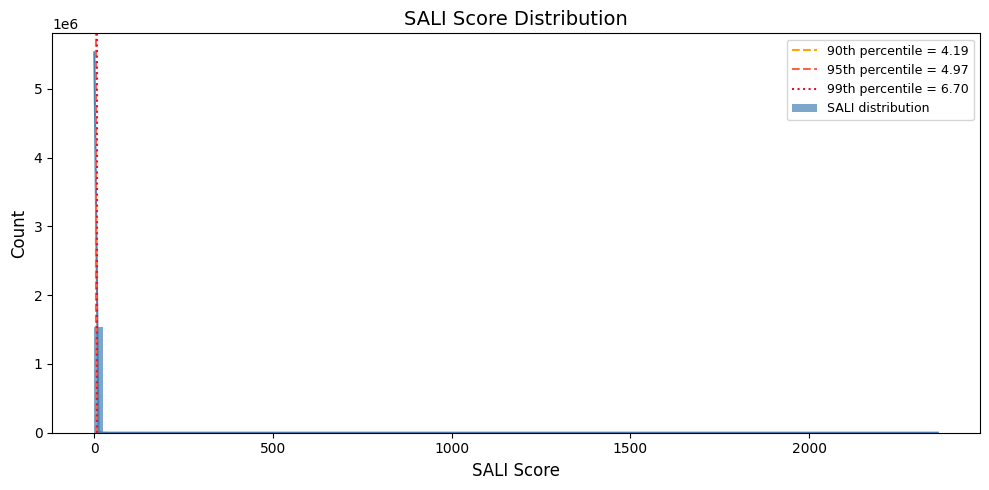

In [26]:
fig, ax = plot_sali_distribution(
    df_sali,
    fixed_threshold=None,
    log_scale=False,
)

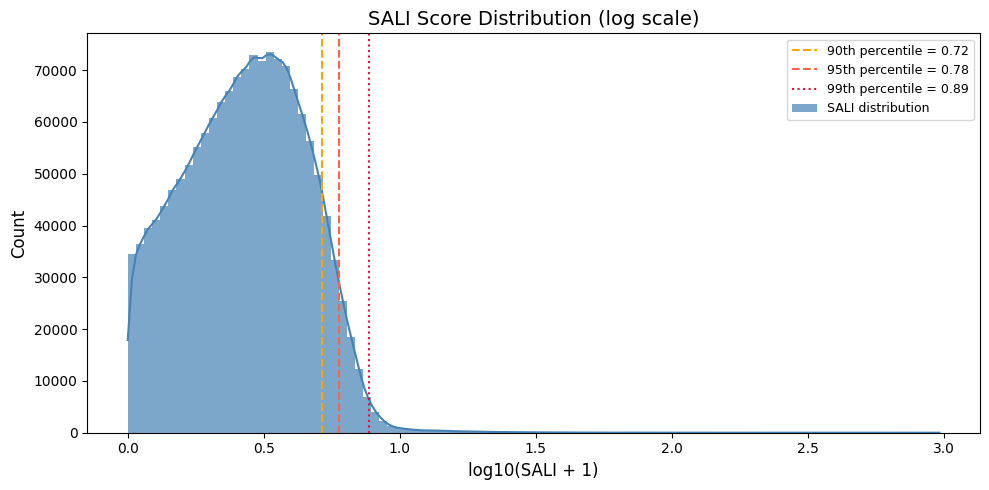

In [27]:
# plot the compounds with sali below 1000
fig, ax = plot_sali_distribution(
    df_sali.query("SALI < 1000"),
    fixed_threshold=None,
    log_scale=True,
)

In [28]:
# can make the plot "look better" by arbitrarily adjusting the sali formula
df_sali_05 = compute_sali(
    smiles=df.canonical_smiles.tolist(),
    pic50=df.pchembl_value.values,
    fp_list=fp_list,
    metric="tanimoto",
    n_cpus=6,
    # sali_epsilon=0.001,
    sali_epsilon=0.05,
    )
df_sali_05.shape

WARNING | Found 44 group(s) of identical SMILES affecting 113 compounds.
Group sizes: [9, 8, 6, 4, 4, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2].
These pairs will have Sim = 1.0 and may reflect unresolved stereochemistry.
SALI is still computed using denominator epsilon (default 0.001).
INFO | Computing upper-triangle tanimoto similarities: 1751 compounds -> 1,532,125 unique pairs using 6 CPU(s)...
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:    0.6s
[Parallel(n_jobs=6)]: Done  60 tasks      | elapsed:    2.8s
[Parallel(n_jobs=6)]: Done 150 tasks      | elapsed:    6.6s
[Parallel(n_jobs=6)]: Done 276 tasks      | elapsed:   11.8s
[Parallel(n_jobs=6)]: Done 438 tasks      | elapsed:   18.4s
[Parallel(n_jobs=6)]: Done 636 tasks      | elapsed:   26.3s
[Parallel(n_jobs=6)]: Done 870 tasks      | elapsed:   35.7s
[Parallel(n_jobs=6)]: 

(1532125, 9)

In [29]:
df_sali_05

,compound_i,compound_j,SMILES_i,SMILES_j,pIC50_i,pIC50_j,delta_pIC50,tanimoto_similarity,SALI
0,1225,1565,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,9.32,6.96,2.36,1.00000,47.20000
1,1225,1424,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,9.32,7.00,2.32,1.00000,46.40000
2,1171,1565,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,9.07,6.96,2.11,1.00000,42.20000
3,1229,1230,COc1ccc(C(=O)OCCN(C)C)cc1NC(=O)Nc1cc(-c2ccc3[n...,CCN(CC)CCOC(=O)c1ccc(OC)c(NC(=O)Nc2cc(-c3ccc4[...,4.28,6.80,2.52,0.98914,41.40803
4,1171,1424,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,9.07,7.00,2.07,1.00000,41.40000
...,...,...,...,...,...,...,...,...,...
1532120,18,1186,CN(c1ccc(NC(=O)Oc2ccccc2)cc1)c1ccnc(Nc2cccc(CS...,COc1ccc(C(=O)Nc2ccc(OCCN3CCCCC3)c(Cl)c2)c(-c2c...,7.02,7.02,0.00,0.32151,0.00000
1532121,1389,1441,Cc1nn(-c2ccnc(Nc3ccc4c(c3)c(Cl)c(C)n4C)n2)cc1C...,Cc1ccc(NC(=O)CN2CCN(c3nnc(-c4ccccc4)c4ccccc34)...,5.37,5.37,0.00,0.35390,0.00000
1532122,67,653,CONC(=O)c1cc(Nc2ncnn3cc(-c4nnc(N(C)C)o4)c(C(C)...,Cc1cccc(NC(=O)Nc2ccc(-c3csc4ncnc(N)c34)c(F)c2)c1,7.96,7.96,0.00,0.45119,0.00000
1532123,93,178,CONC(=O)c1cc(Nc2ncnn3cc(NC(=O)OCc4ccccc4)c(C(C...,COc1cc(OC)cc(-c2cc3cnc(NCCCCOc4ccccc4)cc3nc2NC...,6.75,6.75,0.00,0.42958,0.00000


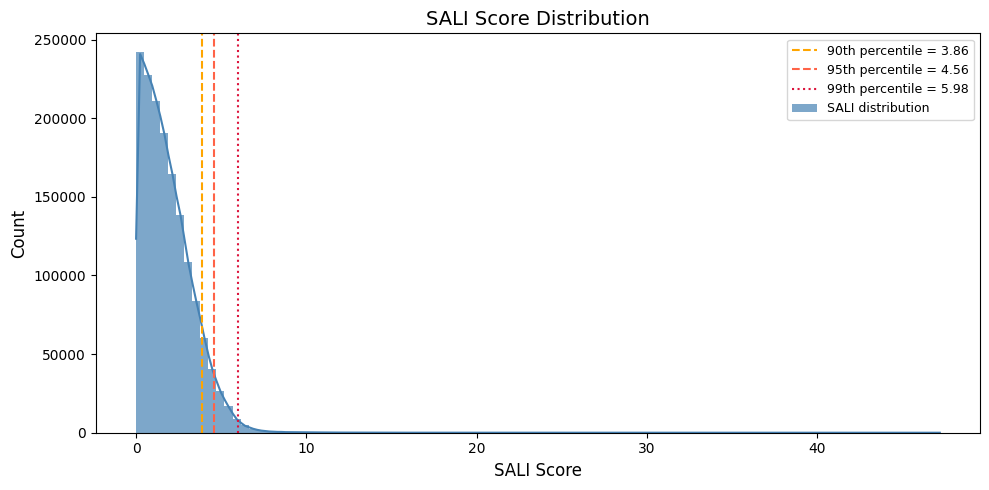

In [30]:
fig, ax = plot_sali_distribution(
    df_sali_05,
    fixed_threshold=None,
    log_scale=False,
)

# Step 6) Visualize the pairs with top SALI values

In [31]:
def align_mols(smi_i, smi_j):
    mol_i = Chem.MolFromSmiles(smi_i)
    mol_j = Chem.MolFromSmiles(smi_j)

    mcs = rdFMCS.FindMCS([mol_i, mol_j], completeRingsOnly=True)
    if mcs.numAtoms > 0:
        mcs_query = Chem.MolFromSmarts(mcs.smartsString)
        AllChem.Compute2DCoords(mcs_query)
        AllChem.GenerateDepictionMatching2DStructure(mol_i, mcs_query)
        AllChem.GenerateDepictionMatching2DStructure(mol_j, mcs_query)
        # GetSubstructMatch returns the atom indices in each mol that
        # correspond to the MCS query — these are the atoms to highlight
        mcs_atoms_i = mol_i.GetSubstructMatch(mcs_query)
        mcs_atoms_j = mol_j.GetSubstructMatch(mcs_query)
    else:
        AllChem.Compute2DCoords(mol_i)
        AllChem.Compute2DCoords(mol_j)
        mcs_atoms_i, mcs_atoms_j = (), ()

    return mol_i, mol_j, mcs_atoms_i, mcs_atoms_j

In [32]:
def _get_mcs_bond_indices(mol, atom_indices: list) -> list:
    """Return indices of bonds where both endpoints are in atom_indices."""
    atom_set = set(atom_indices)
    return [
        bond.GetIdx()
        for bond in mol.GetBonds()
        if bond.GetBeginAtomIdx() in atom_set
        and bond.GetEndAtomIdx() in atom_set
    ]

In [33]:
def show_top_n_cliffs(df_sali: pd.DataFrame, n: int = 5, save_path: str = None):
    """
    Draw the top N activity cliff pairs in a single grid (N rows x 2 columns).

    The more active compound (compound_i, higher pIC50) is always on the left.
    Molecules within each pair are aligned to their Maximum Common Substructure.

    Parameters
    ----------
    df_sali : pd.DataFrame
        SALI dataframe, sorted by SALI descending. Must have columns:
        SMILES_i, SMILES_j, compound_i, compound_j,
        pIC50_i, pIC50_j, delta_pIC50, tanimoto_similarity, SALI.
    n : int
        Number of top pairs to show. Default 5.
    save_path : str, optional
        If provided, saves the image to this path (e.g. 'cliffs.png').

    Returns
    -------
    PIL.Image
    """
    mols, legends, highlight_atoms = [], [], []

    for rank, (_, row) in enumerate(df_sali.head(n).iterrows(), start=1):
        mol_i, mol_j, mcs_i, mcs_j = align_mols(row["SMILES_i"], row["SMILES_j"])
        fold_diff = 10 ** row["delta_pIC50"]
        mols             += [mol_i, mol_j]
        highlight_atoms  += [list(mcs_i), list(mcs_j)]
        legends          += [
            f"#{rank} Compound {row['compound_i']} | pIC50={row['pIC50_i']:.2f} "
            f"| SALI={row['SALI']:.1f} | Tan={row['tanimoto_similarity']:.2f} | {fold_diff:.0f}x",
            f"#{rank} Compound {row['compound_j']} | pIC50={row['pIC50_j']:.2f}",
        ]

    HIGHLIGHT_COLOR = (0.4, 0.9, 0.1)  # bright green
    HIGHLIGHT_COLOR = (0.6, 0.8, 0.6)  # muted sage green
    # build per-atom and per-bond color dicts keyed to actual MCS atom/bond indices
    atom_colors  = [{idx: HIGHLIGHT_COLOR for idx in atom_list} for atom_list in highlight_atoms]
    bond_colors  = [{idx: HIGHLIGHT_COLOR for idx in _get_mcs_bond_indices(mol, atom_list)}
                    for mol, atom_list in zip(mols, highlight_atoms)]

    img = MolsToGridImage(
        mols,
        molsPerRow=2,
        subImgSize=(400, 300),
        legends=legends,
        highlightAtomLists=highlight_atoms,
        highlightAtomColors=atom_colors,
        highlightBondLists=[[] for _ in mols],  # disable bond highlighting
        useSVG=True,
        maxMols=n * 2,
    )

    if save_path:
        with open(save_path, "w") as f:
            f.write(img)

    return img

In [40]:
df_sali_sorted.query("SALI < 8")

,compound_i,compound_j,SMILES_i,SMILES_j,pIC50_i,pIC50_j,delta_pIC50,tanimoto_similarity,SALI
7231,1003,983,NC(=O)Cn1cc(Nc2ncc(Cl)c(N[C@H]3[C@@H](C(N)=O)[...,Cn1cc(Nc2ncc(C(N)=O)c(N[C@H]3[C@@H](C(N)=O)[C@...,7.75,5.81,1.94,0.75847,7.99916
7232,1525,1516,Cc1n[nH]c2nccc(-c3ccc(NC(=O)NC4CC4)cc3)c12,Cc1n[nH]c2nccc(-c3ccc(NC(=O)NCC(C)C)cc3)c12,5.34,5.06,0.28,0.96599,7.99885
7233,1308,1296,Nc1ncc2c(n1)CCN(c1cccc(C(=O)Nc3ccc(F)c(C(F)(F)...,Cc1cc(C(=O)Nc2cccc(C(F)(F)F)c2)cc(N2CCc3ncncc3...,7.57,6.20,1.37,0.82972,7.99880
7234,760,202,CCN(CC)CCn1c2ccc(C3CCCCO3)cc2c2c3c(c4c(c21)CCc...,COc1cc(OC)cc(C2Cc3cnc(N(CCCCCOCc4ccccc4)C(C)=O...,7.80,4.26,3.54,0.55841,7.99844
7235,1604,919,COc1cc2ncnc(Nc3ccc(NC(=O)c4ccccc4C)cc3)c2cc1OC,COc1cc2ncnc(Nc3ccc(NC(=O)Nc4ccccc4)cc3)c2cc1OC,6.94,5.29,1.65,0.79471,7.99841
...,...,...,...,...,...,...,...,...,...
1532120,436,826,Cc1ccc(C(=O)Nc2cccc(C(F)(F)F)c2C)cc1-c1ccc2nc(...,COc1cc2nccc(Oc3ccc4c(C(=O)NC5(C)CC5)cccc4c3)c2...,7.82,7.82,0.00,0.35178,0.00000
1532121,319,1429,FC(F)(F)Oc1ccc(Nc2nnc(-c3ccncc3CCc3ccncc3)o2)cc1,CCOC(=O)c1ccc(NC(=O)CN2CCN(c3nnc(-c4ccccc4)c4c...,6.46,6.46,0.00,0.32407,0.00000
1532122,58,664,CC(C)OCc1ccc2c(c1)c1c3c(c4c(c1n2CCCCC(=O)N(C)C...,CONC(=O)c1cc(Nc2ncnn3cc(-c4nnc(C)o4)c(C(C)C)c2...,7.75,7.75,0.00,0.59177,0.00000
1532123,145,832,Cc1ccc(Nc2ncnn3cc(OCCCN4CCCCC4)c(C(C)C)c23)cc1O,O=C(Nc1ccc(Cl)cc1)c1cccc2cc(Oc3ccnc4ccccc34)ccc12,8.40,8.40,0.00,0.31434,0.00000


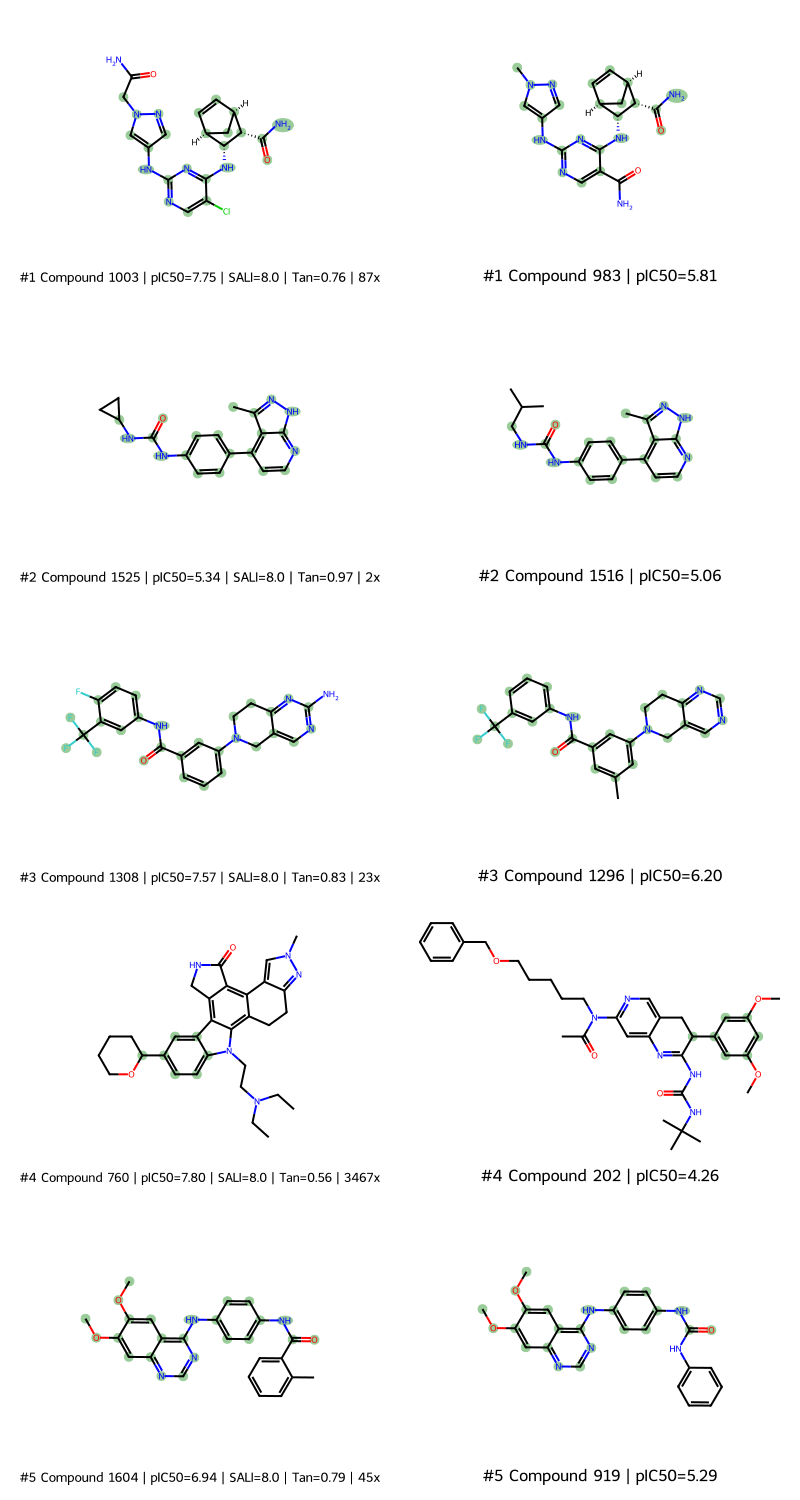

In [41]:
img = show_top_n_cliffs(df_sali_sorted.query("SALI < 8"),
                        n=5,
                        # save_path="top5_cliffs.png",
                       )
display(img)